In [1]:
import json
import numpy as np
import os
from typing import List, Tuple

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from datetime import datetime, timedelta
import matplotlib.ticker as ticker
from tensorboard.backend.event_processing import event_accumulator
from tensorflow.python.framework import tensor_util

def update_plot_config():
    plt.rcParams.update({
        "text.usetex": True,
        "font.family": "serif",
        "font.serif": ["Times"],
        "axes.labelsize": 10,
        "font.size": 10,
        "legend.fontsize": 9,
        "xtick.labelsize": 8,
        "ytick.labelsize": 8,
    })

def plot_actions(file_path: str, name: str):

    update_plot_config()
    

    with open(file_path, 'r') as f:
        data = json.load(f)


    actions = np.array(data['actions'])
    timestamps = data['timestamps']
    parsed_times = [datetime.fromisoformat(t) for t in timestamps]


    plt.figure(figsize=(4, 2), dpi=300)

    # Plot actions
    plt.plot(parsed_times, actions[:, 0], color='crimson', linewidth=1.5, label='Action 1')
    plt.plot(parsed_times, actions[:, 1], color='navy', linewidth=1.5, label='Action 2')


    ax = plt.gca()
    locator = mdates.AutoDateLocator()
    formatter = mdates.ConciseDateFormatter(locator)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)


    plt.xticks(rotation=30, ha='right', fontsize=8)
    plt.xlabel('Time', fontsize=12)
    plt.ylabel('Action Value', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.tight_layout()
    plt.legend(loc='upper right')
    

    plt.savefig(f'plots/{name}.pdf', bbox_inches='tight')
    
    return parsed_times, actions


2025-05-03 14:13:55.136451: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2025-05-03 14:13:55.136513: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2025-05-03 14:13:55.139222: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2025-05-03 14:13:55.154889: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-05-03 14:13:56.585302: W tensorflow/comp

([datetime.datetime(2023, 8, 6, 0, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))),
  datetime.datetime(2023, 8, 6, 0, 30, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))),
  datetime.datetime(2023, 8, 6, 0, 45, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))),
  datetime.datetime(2023, 8, 6, 1, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))),
  datetime.datetime(2023, 8, 6, 1, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))),
  datetime.datetime(2023, 8, 6, 1, 30, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))),
  datetime.datetime(2023, 8, 6, 1, 45, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))),
  datetime.datetime(2023, 8, 6, 2, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))),
  datetime.datetime(2023, 8, 6, 2, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=61200))),
  datetime.d

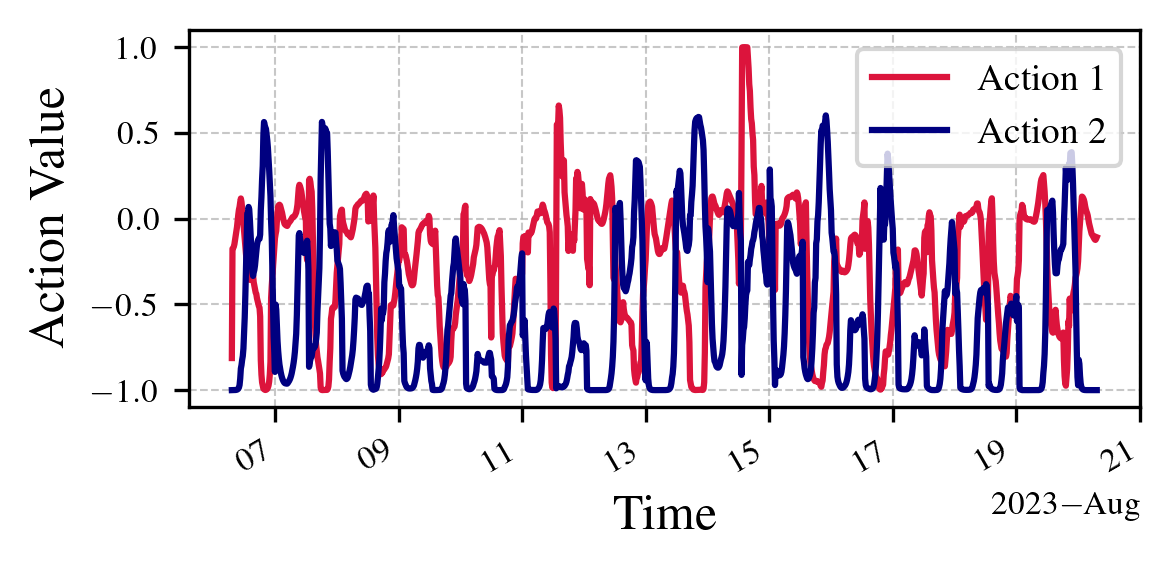

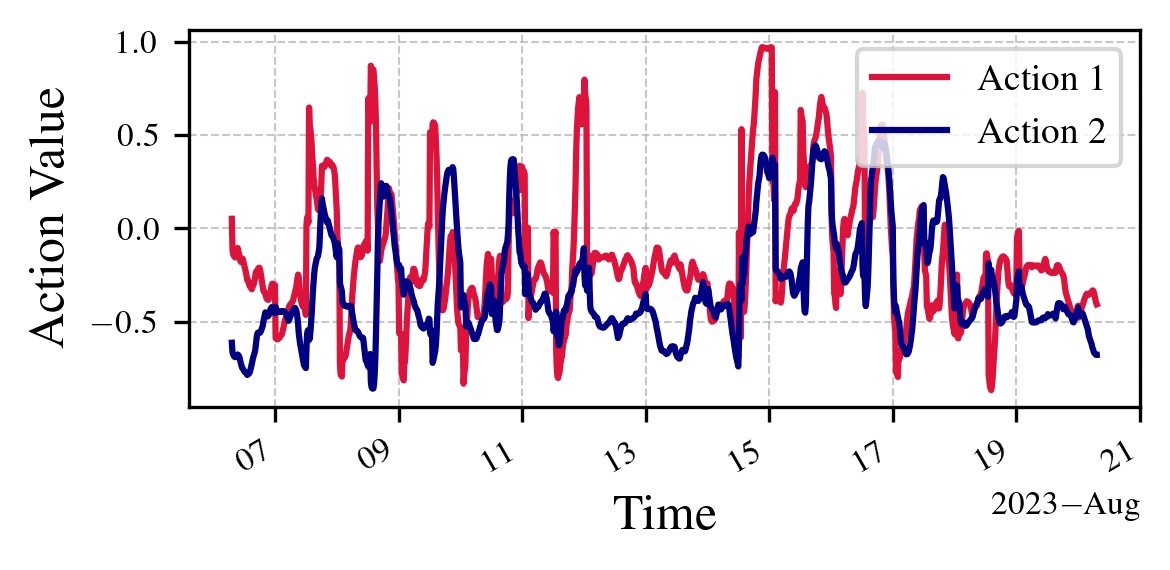

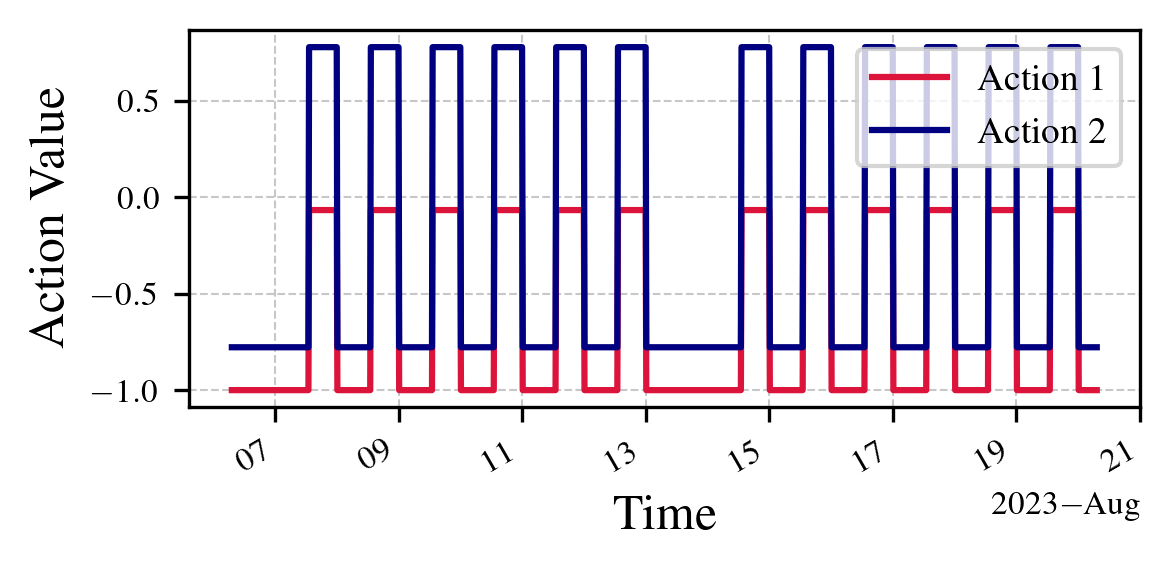

In [2]:
parsed_times, actions = plot_actions('eval_results/ddpg_train-summer_eval-08-06_2025_04_15-01:44:58/trajectories/episode_0.json', 'ddpg_eval_08_06_2025')
plot_actions('eval_results/sac_train-summer_eval-08-06_2025_04_15-01:43:44/trajectories/episode_0.json', 'sac_eval_08_06_2025')
plot_actions('eval_results/schedule_eval-08-06_2025_04_15-01:46:14/trajectories/episode_0.json', 'schedule_eval_08_06_2025')

In [3]:
def aggregate_actions_by_time(
    actions: np.ndarray,
    parsed_times: List[datetime],
    aggregation_timedelta: timedelta
) -> Tuple[np.ndarray, List[datetime]]:
    """
    Aggregates actions by averaging them over specified time intervals.

    Args:
        actions: A numpy array of shape (N, D) where N is the number of
                 timesteps and D is the dimension of the action space.
        parsed_times: A list of N datetime objects corresponding to each action.
                      Assumes the list might not be sorted initially.
        aggregation_timedelta: A datetime.timedelta object specifying the
                               duration of each aggregation interval (e.g., timedelta(hours=2)).

    Returns:
        A tuple containing:
        - aggregated_actions_array: A numpy array of shape (M, D) containing
                                     the average action for each non-empty interval,
                                     where M is the number of non-empty intervals found.
        - interval_start_times: A list of M datetime objects representing the
                                 start time of each corresponding interval in
                                 aggregated_actions_array.

    Raises:
        ValueError: If the lengths of actions and parsed_times do not match.
        TypeError: If inputs are not of the expected types.
    """
    # --- Input Validation ---
    if not isinstance(actions, np.ndarray):
        raise TypeError("actions must be a numpy array.")
    if actions.ndim != 2:
         raise ValueError(f"actions must be a 2D array, but got shape {actions.shape}")
    if not isinstance(parsed_times, list):
        raise TypeError("parsed_times must be a list.")
    if not all(isinstance(t, datetime) for t in parsed_times):
        raise TypeError("All elements in parsed_times must be datetime objects.")
    if not isinstance(aggregation_timedelta, timedelta):
        raise TypeError("aggregation_timedelta must be a datetime.timedelta object.")
    if len(actions) != len(parsed_times):
        raise ValueError(f"actions (len {len(actions)}) and parsed_times (len {len(parsed_times)}) must have the same length.")
    if aggregation_timedelta <= timedelta(0):
        raise ValueError("aggregation_timedelta must be positive.")

    # --- Handle Empty Input ---
    if len(parsed_times) == 0:
        # Return empty array with correct second dimension if possible, else shape (0,0)
        action_dim = actions.shape[1] if actions.ndim == 2 else 0
        return np.array([]).reshape(0, action_dim) , []

    # --- Sort data by time (crucial for interval processing) ---
    # Combine, sort by time, then separate again
    try:
        sorted_pairs = sorted(zip(parsed_times, list(actions)), key=lambda pair: pair[0])
        sorted_times, sorted_actions_list = zip(*sorted_pairs)
        # Convert actions back to numpy array *after* sorting
        sorted_actions = np.array(sorted_actions_list)
        sorted_times = list(sorted_times) # Keep as list for easier comparison
    except Exception as e:
         # Handle potential issues if actions rows aren't easily convertible back
         print(f"Error during sorting: {e}")
         # Fallback to less efficient method or raise error depending on needs
         # For now, let's re-raise to indicate a problem
         raise ValueError("Could not sort actions and times. Check action array structure.") from e


    # --- Initialization ---
    aggregated_actions = []
    interval_start_times = []

    min_time = sorted_times[0]
    max_time = sorted_times[-1]

    current_interval_start = min_time
    # Optimization: Keep track of the index in sorted_times to start searching from
    current_data_idx = 0

    # --- Iterate through Time Intervals ---
    while current_interval_start <= max_time: # Include intervals starting exactly at max_time
        current_interval_end = current_interval_start + aggregation_timedelta
        indices_in_interval = []

        # Find data points within the current interval [start, end)
        # Use the current_data_idx for efficiency since data is sorted
        temp_idx = current_data_idx
        while temp_idx < len(sorted_times):
            timestamp = sorted_times[temp_idx]
            if timestamp >= current_interval_end:
                # This timestamp is beyond the current interval, stop searching for this interval
                break
            # No need to check >= current_interval_start because we advance current_data_idx
            # and we only consider timestamps from that point forward.
            # Update: Actually, the first item(s) might be exactly current_interval_start,
            # so the check IS implicitly handled correctly by starting search at current_data_idx.
            # Let's add an explicit check just for absolute clarity, though it shouldn't change behaviour
            # given the sorted nature and how current_data_idx is updated.
            # if timestamp >= current_interval_start: # This check is technically redundant here.
            indices_in_interval.append(temp_idx)
            temp_idx += 1

        # --- Calculate Average if Interval is Not Empty ---
        if indices_in_interval:
            # Select the actions corresponding to the found indices
            actions_in_interval = sorted_actions[indices_in_interval]
            # Calculate the mean along the time axis (axis=0)
            average_action = np.mean(actions_in_interval, axis=0)

            aggregated_actions.append(average_action)
            interval_start_times.append(current_interval_start)

            # Optimization: Update the starting index for the *next* interval's search.
            # The next interval will start searching from the first item that
            # was *not* included in this interval (i.e. >= current_interval_end)
            # or the end of the list if all remaining items were in this interval.
            # The index `temp_idx` calculated in the inner loop is exactly this.
            current_data_idx = temp_idx # Start next search from where this one stopped.

        else:
            # If the interval is empty, we still need to advance the current_data_idx
            # past any timestamps that are less than the *next* interval's start time.
            temp_idx = current_data_idx
            next_interval_start = current_interval_end # same as current_interval_end
            while temp_idx < len(sorted_times) and sorted_times[temp_idx] < next_interval_start:
                 temp_idx += 1
            current_data_idx = temp_idx


        # --- Move to the next interval ---
        current_interval_start = current_interval_end

    # --- Final Conversion ---
    # Convert the list of average action arrays into a single 2D numpy array
    if not aggregated_actions: # Handle case where no intervals had data
         action_dim = actions.shape[1] if actions.ndim == 2 else 0
         return np.array([]).reshape(0, action_dim), []
    else:
        aggregated_actions_array = np.array(aggregated_actions)
        return aggregated_actions_array, interval_start_times

In [4]:
def extract_tensorboard_data(logdir: str, tag: str, sample_rate: int=50):
    size_guidance = { event_accumulator.TENSORS: 0 } # Load all tensors
    ea = event_accumulator.EventAccumulator(logdir, size_guidance=size_guidance)
    ea.Reload()

    if tag in ea.Tags()['tensors']:
        events = ea.Tensors(tag)
        steps = [e.step for e in events]
        values = [tensor_util.MakeNdarray(e.tensor_proto).item() for e in events]
            
    return steps[::sample_rate], values[::sample_rate]


def calculate_ema(values, alpha):
    """Calculates the Exponential Moving Average."""
    values = np.array(values, dtype=float)
    if values.size == 0:
        return np.array([])
    ema_values = np.zeros_like(values, dtype=float)
    ema_values[0] = values[0]
    for i in range(1, len(values)):
        ema_values[i] = alpha * values[i] + (1 - alpha) * ema_values[i-1]
    return ema_values


def plot_loss(steps: list | np.ndarray, 
              loss_values: list | np.ndarray, 
              tag_name: str, 
              save_name: str, 
              plot_dir: str = 'plots',
              ylim: tuple[float, float] | None = None, # User-defined y-axis limits
              color: str = 'tab:cyan', 
              log_scale_y: bool = False,
              smoothing_weight: float = 0.6, 
              raw_alpha: float = 0.3):
        
    update_plot_config() 
    fig, ax = plt.subplots(figsize=(4, 2))
    steps = np.array(steps)
    loss_values = np.array(loss_values)
    
    # --- Smoothing ---
    smoothed_values = None
    smoothing_weight = max(0.0, min(1.0, smoothing_weight)) 
    if smoothing_weight > 0:
        alpha = 1.0 - smoothing_weight 
        smoothed_values = calculate_ema(loss_values, alpha)

    # --- Plotting Lines ---
    tag_name_latex = tag_name.replace('_', r'\_') if plt.rcParams['text.usetex'] else tag_name

    # Plot Raw Data
    ax.plot(steps, loss_values, color=color, linewidth=1.0, 
            alpha=raw_alpha, label=f'{tag_name_latex} (Raw)')

    # Plot Smoothed Data
    if smoothed_values is not None:
        ax.plot(steps, smoothed_values, color=color, linewidth=1.5, 
                alpha=1.0, label=f'{tag_name_latex} (Smoothed, w={smoothing_weight:.2f})')

    # --- Axis Configuration ---
    ax.set_xlabel('Training Step', fontsize=12)
    ax.set_ylabel('Loss Value', fontsize=12)
    
    # X-axis tick formatting
    def format_thousands(x, pos):
        if x >= 1e6: return f'{x*1e-6:.0f}M'
        if x >= 1e3: return f'{x*1e-3:.0f}k'
        return f'{x:.0f}'
    ax.xaxis.set_major_formatter(ticker.FuncFormatter(format_thousands))
    
    ax.tick_params(axis='x', labelsize=8) 
    ax.tick_params(axis='y', labelsize=8)

    # Y-axis scale and limits
    if log_scale_y:
        ax.set_yscale('log')
    # Apply user-defined limits if provided
    if ylim is not None:
        ax.set_ylim(ylim)
        
    # Set x-axis limits
    ax.set_xlim(left=0, right=steps.max() * 1.02 if steps.size > 0 else 1) 

    # --- Final Touches ---
    ax.grid(True, which='major', linestyle='--', linewidth=0.5, alpha=0.7) 
    
    plt.tight_layout() 
    plt.legend(loc='best')

    # --- Saving ---
    os.makedirs(plot_dir, exist_ok=True)
    save_path = os.path.join(plot_dir, f"{save_name}.pdf")
    plt.savefig(save_path, bbox_inches='tight')
    plt.close(fig)

In [5]:
log_directory = 'experiment_results/ddpg_train_run-july-6th_2025_04_07-12:50:40/train/'
target_tag = 'Losses/critic_loss'
steps, values = extract_tensorboard_data(log_directory, target_tag)
save_file_name = 'ddpg_critic_loss_july_6th_2025'
plot_loss(
        steps=steps, 
        loss_values=values, 
        tag_name=target_tag, 
        save_name=save_file_name, 
        ylim=(0, 0.02), # Set desired y-limits here
        log_scale_y=True,
        smoothing_weight=0.8, # Example smoothing
        color="crimson"
)

log_directory = 'experiment_results/ddpg_train_run-july-6th_2025_04_07-12:50:40/train/'
target_tag = 'Losses/actor_loss'
steps, values = extract_tensorboard_data(log_directory, target_tag)
save_file_name = 'ddpg_actor_loss_july_6th_2025'
plot_loss(
        steps=steps, 
        loss_values=values, 
        tag_name=target_tag, 
        save_name=save_file_name, 
        ylim=(0.001, 0.05), # Set desired y-limits here
        log_scale_y=True,
        smoothing_weight=0.8, # Example smoothing
        color="crimson"
)

/tmp/ipykernel_3356062/333202574.py:80: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim)


In [6]:
log_directory = 'experiment_results/sac_train_run-july-6th_2025_04_04-06:49:50/train/'
target_tag = 'Losses/critic_loss'
steps, values = extract_tensorboard_data(log_directory, target_tag, sample_rate=1)
save_file_name = 'sac_critic_loss_july_6th_2025'
plot_loss(
        steps=steps, 
        loss_values=values, 
        tag_name=target_tag, 
        save_name=save_file_name, 
        ylim=(0, 0.08), # Set desired y-limits here
        log_scale_y=True,
        smoothing_weight=0.8, # Example smoothing
        color="crimson"
)

log_directory = 'experiment_results/sac_train_run-july-6th_2025_04_04-06:49:50/train/'
target_tag = 'Losses/actor_loss'
steps, values = extract_tensorboard_data(log_directory, target_tag, sample_rate=1)
save_file_name = 'sac_actor_loss_july_6th_2025'
plot_loss(
        steps=steps, 
        loss_values=values, 
        tag_name=target_tag, 
        save_name=save_file_name, 
        ylim=(-5, 1.4), # Set desired y-limits here
        log_scale_y=False,
        smoothing_weight=0.5, # Example smoothing
        color="crimson"
)


log_directory = 'experiment_results/sac_train_run-july-6th_2025_04_04-06:49:50/train/'
target_tag = 'Losses/alpha_loss'
steps, values = extract_tensorboard_data(log_directory, target_tag, sample_rate=1)
save_file_name = 'sac_alpha_loss_july_6th_2025'
plot_loss(
        steps=steps, 
        loss_values=values, 
        tag_name=target_tag, 
        save_name=save_file_name, 
        ylim=(-10, 1), # Set desired y-limits here
        log_scale_y=False,
        smoothing_weight=0.8, # Example smoothing
        color="crimson"
)

/tmp/ipykernel_3356062/333202574.py:80: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(ylim)


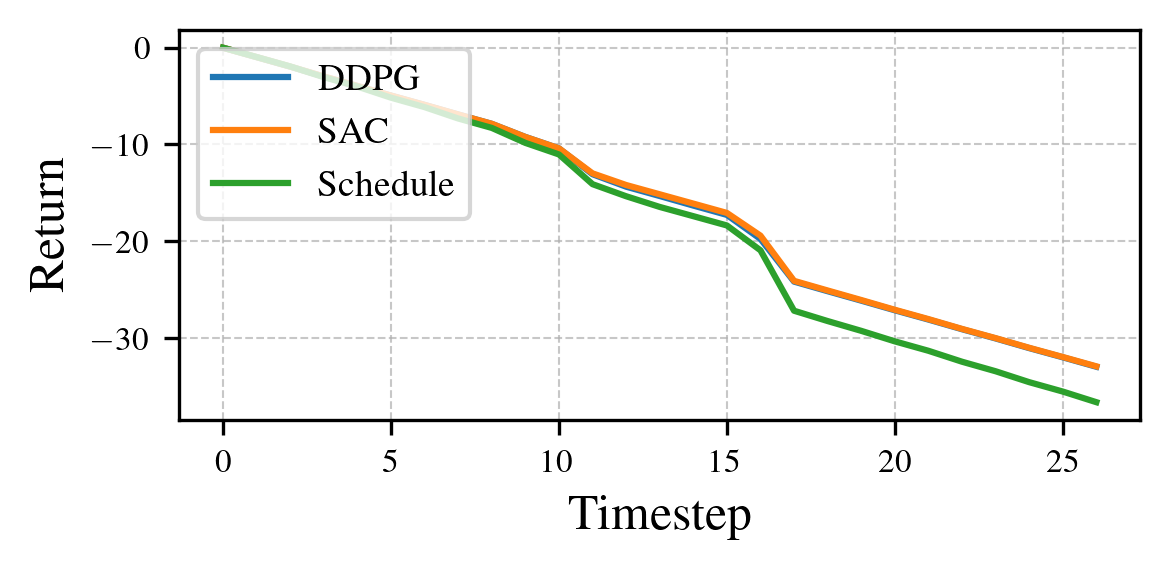

In [7]:
def plot_cumulative_reward_comparison_plot(experiment_paths: List[str], labels: List[str], name: str):
    update_plot_config()
    plt.figure(figsize=(4, 2), dpi=300)

    for i, path in enumerate(experiment_paths):
        with open(path, 'r') as f:
            data = json.load(f)
        rewards = np.cumsum(data['rewards'])[::50]
        label = labels[i]
        plt.plot(rewards, linewidth=1.5, label=label)

    plt.xlabel('Timestep', fontsize=12)
    plt.ylabel('Return', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.xticks(fontsize=8)
    plt.tight_layout()
    plt.legend(loc='upper left')
    plt.savefig(f'plots/{name}.pdf', bbox_inches='tight')
    
plot_cumulative_reward_comparison_plot([
    'eval_results/ddpg_train-summer_eval-08-06_2025_04_15-01:44:58/trajectories/episode_0.json',
    'eval_results/sac_train-summer_eval-08-06_2025_04_15-01:43:44/trajectories/episode_0.json',
    'eval_results/schedule_eval-08-06_2025_04_15-01:46:14/trajectories/episode_0.json'
    ],
    labels=['DDPG', 'SAC', 'Schedule'],
    name='cumulative_reward_comparison_08_06_2025')

In [8]:
steps_ddpg, values_ddpg = extract_tensorboard_data(
    logdir='experiment_results/ddpg_train_run-july-6th_2025_04_07-12:50:40/eval/',
    tag='Metrics/AverageReturn', sample_rate=1
)
steps_sac, values_sac = extract_tensorboard_data(
    logdir='experiment_results/sac_train_run-july-6th_2025_04_04-06:49:50/eval/',
    tag='Metrics/AverageReturn', sample_rate=1
)

In [9]:
def plot_comparison_curves(
    curves: List[Tuple[np.ndarray, np.ndarray, str]],
    name: str,
    baseline_value: float = -167.53,
    baseline_label: str = 'schedule'
):
    # update_plot_config() # Optional plot configuration
    plt.figure(figsize=(4, 2), dpi=300)

    colors = ['crimson', 'navy', 'forestgreen', 'goldenrod']
    for i, (steps, values, label) in enumerate(curves):
        plt.plot(steps, values, color=colors[i % len(colors)], linewidth=1.5, label=label)

    # Add the horizontal baseline line
    plt.axhline(y=baseline_value, color='darkorange', linestyle='--', linewidth=1.0, label=baseline_label)

    plt.xlabel('Timestep', fontsize=12)
    plt.ylabel('Episode Return', fontsize=12)
    plt.grid(True, which='both', linestyle='--', linewidth=0.5, alpha=0.7)
    plt.xticks(fontsize=8)
    plt.yticks(fontsize=8)
    plt.tight_layout()
    plt.legend(loc='upper left', fontsize=8) # Keep legend for clarity

    # Save the plot (assumes 'plots' directory exists)
    plt.savefig(f'plots/{name}.pdf', bbox_inches='tight')
    plt.close() # Close the figure
    
plot_comparison_curves([
    (steps_ddpg, values_ddpg, 'DDPG'),
    (steps_sac, values_sac, 'SAC')
], name='eval_training_curves_july_6th_2025')

In [10]:
def plot_grouped_bar_results(name: str):
    """Generates and saves a grouped bar plot of agent performance."""
    update_plot_config()

    # Data
    dates = ['Aug 6th', 'Sept 6th', 'Oct 6th', 'Nov 6th']
    schedule_returns = np.array([-37.45, -129.36, -123.89, -198.09])
    sac_returns = np.array([-33.72, -95.66, -91.25, -167.73])
    ddpg_returns = np.array([-33.77, -88.11, -86.7, -162.7])

    x = np.arange(len(dates))  # Label locations
    width = 0.25  # Width of the bars
    multiplier = 0

    fig, ax = plt.subplots(figsize=(4, 2), dpi=300, layout='constrained') # Adjusted size

    # Plotting bars for each agent
    agents = {'Schedule': schedule_returns, 'SAC': sac_returns, 'DDPG': ddpg_returns}
    # Consistent colors with the line plot example, using gray for baseline
    colors = {'Schedule': 'darkgrey', 'SAC': 'navy', 'DDPG': 'crimson'}

    for agent, returns in agents.items():
        offset = width * multiplier
        # Added edgecolor='black' and linewidth for the outline
        rects = ax.bar(
            x + offset,
            returns,
            width,
            label=agent,
            color=colors[agent],
            edgecolor='black', # Add black edge color
            linewidth=0.75     # Set edge line width
        )
        # Optional: Add labels on top of bars if needed, might be cluttered
        # ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=6)
        multiplier += 1

    # Add labels, title, and ticks
    ax.set_ylabel('Episode Return', fontsize=10) # Match axes label size
    # ax.set_title('Agent Performance Comparison by Month') # Optional title
    ax.set_xticks(x + width, dates) # Center ticks between the groups
    ax.legend(loc='best', ncols=3, fontsize=9) # Adjust legend location/cols
    ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7) # Horizontal grid lines
    ax.set_ylim(top=0) # Ensure y-axis starts appropriately for negative values

    # Ensure the 'plots' directory exists
    if not os.path.exists('plots'):
        os.makedirs('plots')

    # Save the plot
    plt.savefig(f'plots/{name}.pdf', bbox_inches='tight')
    plt.close(fig) # Close the figure

# --- Call the function ---
plot_grouped_bar_results(name='agent_performance_comparison_bar_outlined') # Changed name slightly for the new version

In [15]:
def plot_grouped_bar_results(name: str):
    """Generates and saves a grouped bar plot of agent performance."""
    update_plot_config()

    # Data
    dates = ['Aug 6th', 'Sept 6th', 'Oct 6th', 'Nov 6th']
    ddpg_returns = np.array([-33.77, -88.11, -86.69, -162.67])
    agg_2_returns = np.array([-33.79, -88.13, -86.78, -162.96])
    agg_4_returns = np.array([-34.28, -90.65, -90.05, -165.55])
    agg_8_returns = np.array([-34.43, -92.12, -91.64, -168.56])
    agg_168_returns = np.array([-35.72,- 107.31, -102.86, -179.54])
    schedule_returns = np.array([-37.45, -129.36, -123.89, -198.09])

    

    x = np.arange(len(dates))  # Label locations
    width = 0.12  # Width of the bars
    multiplier = 0

    fig, ax = plt.subplots(figsize=(4, 2), dpi=300, layout='constrained') # Adjusted size

    # Plotting bars for each agent
    agents = {
        'DDPG': ddpg_returns,
        '2-Hour': agg_2_returns,
        '4-Hour': agg_4_returns,
        '8-Hour': agg_8_returns,
        '168-Hour': agg_168_returns,
        'Schedule': schedule_returns
    }
    # Consistent colors with the line plot example, using gray for baseline
    colors = {
        'Schedule': 'darkgrey',
        '2-Hour': 'navy',
        '4-Hour': 'crimson',
        '8-Hour': 'forestgreen',
        '168-Hour': 'goldenrod',
        'DDPG': 'purple'
    }

    for agent, returns in agents.items():
        offset = width * multiplier
        # Added edgecolor='black' and linewidth for the outline
        rects = ax.bar(
            x + offset,
            returns,
            width,
            label=agent,
            color=colors[agent],
            edgecolor='black', # Add black edge color
            linewidth=0.75     # Set edge line width
        )
        # Optional: Add labels on top of bars if needed, might be cluttered
        # ax.bar_label(rects, padding=3, fmt='%.2f', fontsize=6)
        multiplier += 1

    # Add labels, title, and ticks
    ax.set_ylabel('Episode Return', fontsize=10) # Match axes label size
    # ax.set_title('Agent Performance Comparison by Month') # Optional title
    ax.set_xticks(x + width, dates) # Center ticks between the groups
    ax.legend(loc='best', ncols=3, fontsize=9) # Adjust legend location/cols
    ax.grid(True, which='major', axis='y', linestyle='--', linewidth=0.5, alpha=0.7) # Horizontal grid lines
    ax.set_ylim(top=0) # Ensure y-axis starts appropriately for negative values

    # Ensure the 'plots' directory exists
    if not os.path.exists('plots'):
        os.makedirs('plots')

    # Save the plot
    plt.savefig(f'plots/{name}.pdf', bbox_inches='tight')
    plt.close(fig) # Close the figure

# --- Call the function ---
plot_grouped_bar_results(name='agent_aggregation_performance_comparison_bar_outlined') # Changed name slightly for the new version

([datetime.datetime(2023, 11, 5, 23, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 5, 23, 30, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 5, 23, 45, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 30, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 45, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 1, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 1, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),


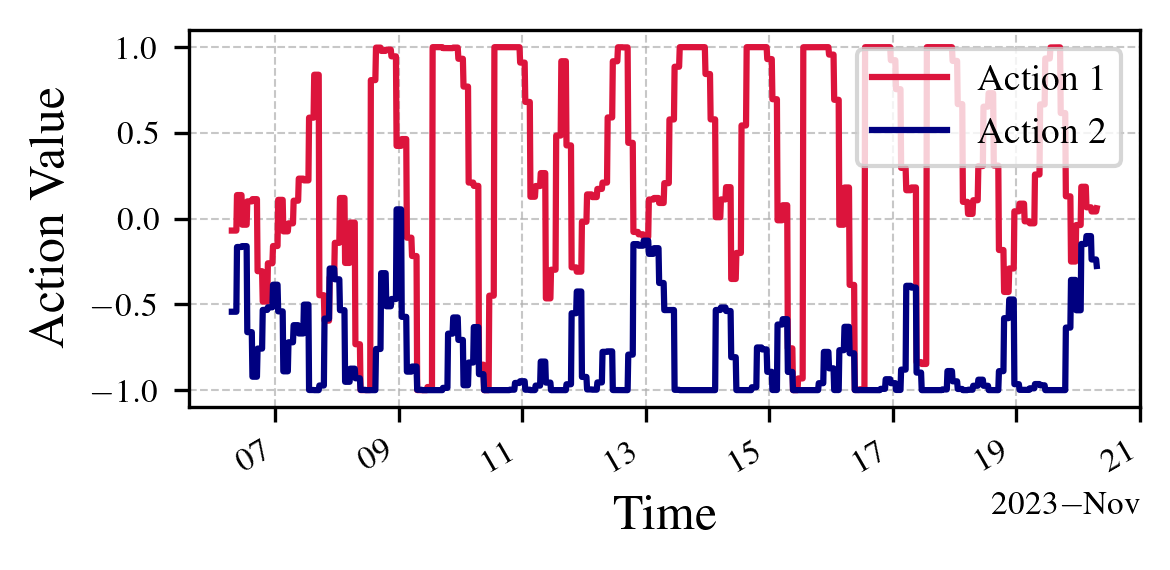

In [19]:
plot_actions('eval_results/aggregate-2_ddpg_train-summer_eval-11-06_2025_05_02-13:09:26/trajectories/episode_0.json', 'ddpg_2_hours_agg_11_06_2025')

([datetime.datetime(2023, 11, 5, 23, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 5, 23, 30, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 5, 23, 45, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 30, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 45, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 1, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 1, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),


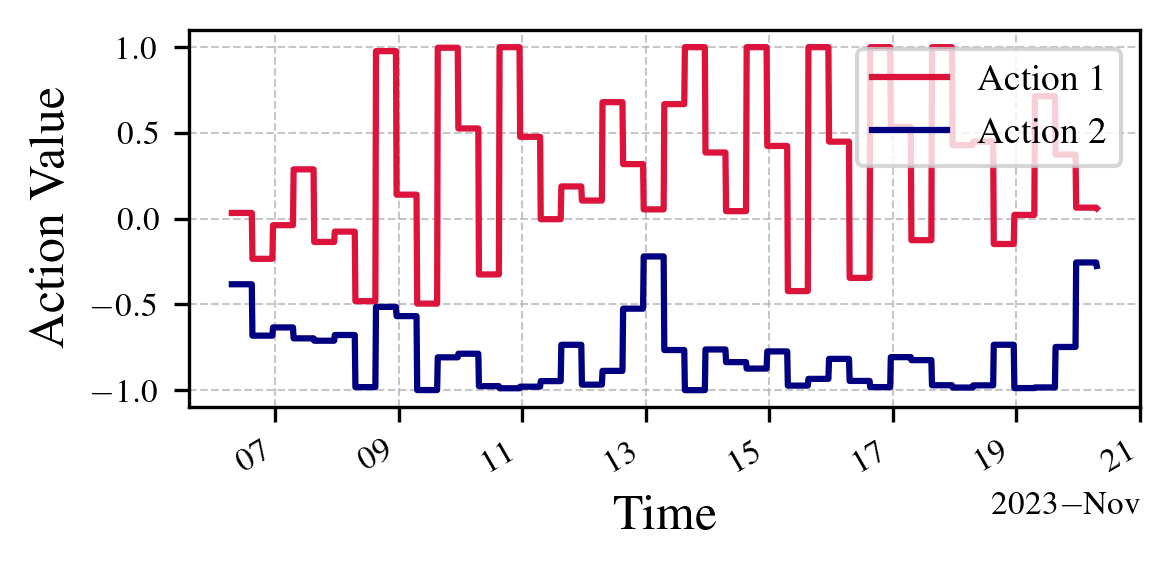

In [20]:
plot_actions('eval_results/aggregate-8_ddpg_train-summer_eval-11-06_2025_05_02-14:00:55/trajectories/episode_0.json', 'ddpg_8_hours_agg_11_06_2025')

([datetime.datetime(2023, 11, 5, 23, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 5, 23, 30, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 5, 23, 45, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 30, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 0, 45, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 1, 0, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),
  datetime.datetime(2023, 11, 6, 1, 15, tzinfo=datetime.timezone(datetime.timedelta(days=-1, seconds=57600))),


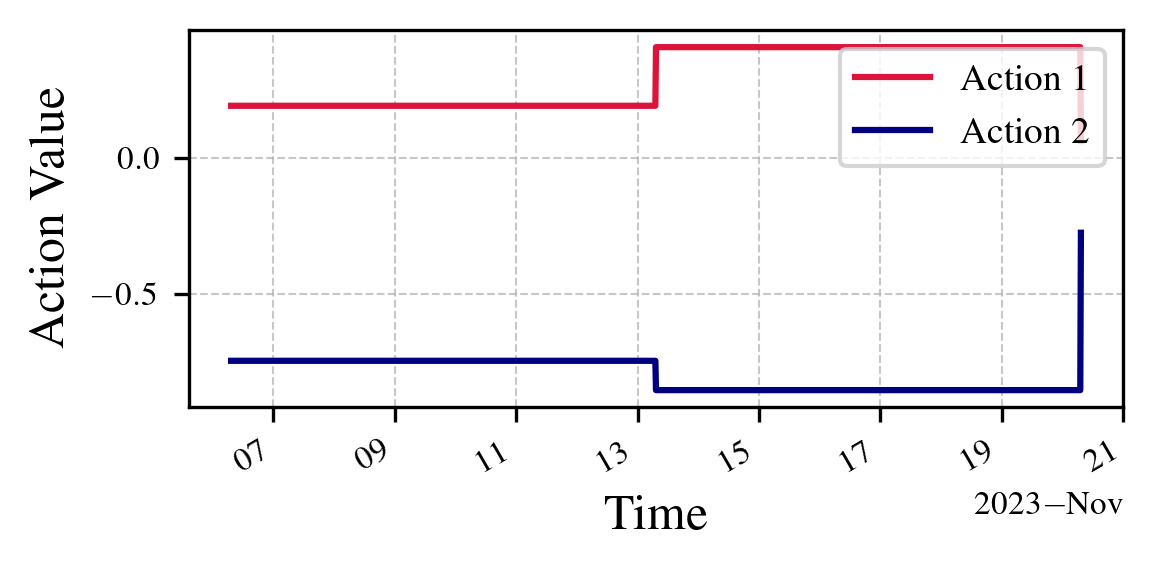

In [21]:
plot_actions('eval_results/aggregate-168_ddpg_train-summer_eval-11-06_2025_05_02-16:36:28/trajectories/episode_0.json', 'ddpg_168_hours_agg_11_06_2025')